# Huấn luyện SLM Intent Router — Qwen2.5-1.5B QLoRA

**Mục tiêu**: Fine-tune Qwen2.5-1.5B-Instruct thành Intent + Scope Router
- 15 intents x 3 scopes = 45 classes
- Input: câu hỏi tiếng Việt về thời tiết Hà Nội
- Output: `{"intent": "...", "scope": "..."}`

**Phương pháp**: QLoRA (4-bit NF4) + Unsloth + TRL SFTTrainer

**Platform**: Google Colab (T4 16GB) / Kaggle (T4/P100)

| Thông số | Giá trị |
|---|---|
| Base model | Qwen2.5-1.5B-Instruct |
| Quantization | 4-bit NF4 (QLoRA) |
| LoRA rank | 16, alpha 32 |
| Train / Val / Test | 1803 / 228 / 228 |
| Scopes | city, district, ward |


## 1. Cài đặt và cấu hình

In [1]:
%%capture
# Cài Unsloth — tự cài transformers, peft, trl, bitsandbytes, xformers
# Colab:
!pip install unsloth
# Kaggle: !pip install unsloth[kaggle-new]

# Pin TRL < 0.16 vì DataCollatorForCompletionOnlyLM bị xóa từ trl>=0.16
!pip install "trl>=0.11,<0.16"


In [2]:
import json
import torch
import numpy as np
import pandas as pd
from pathlib import Path
from collections import Counter
from datasets import Dataset

from unsloth import FastLanguageModel
from trl import SFTTrainer, DataCollatorForCompletionOnlyLM

# Kiểm tra GPU
print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 14.6 GB


In [3]:
# ═══ Hyperparameters ═══
MODEL_NAME = "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit"  # Pre-quantized, nhanh hơn khi load
MAX_SEQ_LENGTH = 640     # Một số sample ~590 tokens, 640 đủ chứa hết

# LoRA
LORA_R = 16              # Rank — 16 phù hợp cho classification với ~1800 samples
LORA_ALPHA = 32          # Alpha = 2*r (scaling factor)
LORA_DROPOUT = 0.0       # Unsloth yêu cầu 0 cho optimized kernels

# Training
EPOCHS = 5               # Với 1803 samples, 5 epochs chưa quá nhiều
BATCH_SIZE = 4           # Per-device batch size (giảm từ 8 để tránh OOM trên T4)
GRAD_ACCUM = 8           # Effective batch = 4 * 8 = 32
LEARNING_RATE = 2e-4     # Standard cho QLoRA
WARMUP_RATIO = 0.1       # 10% warmup
WEIGHT_DECAY = 0.01
LR_SCHEDULER = "cosine"

OUTPUT_DIR = "./outputs/qwen25-intent-router"
SEED = 42

# ═══ Data config ═══
# Google Drive: đặt JSONL files vào thư mục này
DRIVE_PATH = "/content/drive/MyDrive/Chatbot_HanoiAir/data/router"
USE_DRIVE = True  # False = upload trực tiếp


## 2. Load model và áp dụng LoRA

Sử dụng Unsloth để load Qwen2.5-1.5B với 4-bit quantization (NF4).
Unsloth tối ưu memory ~60% và tốc độ ~2x so với HuggingFace thuần.


In [4]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name=MODEL_NAME,
    max_seq_length=MAX_SEQ_LENGTH,
    dtype=None,           # Auto-detect: float16 trên T4, bfloat16 trên A100
    load_in_4bit=True,    # QLoRA 4-bit quantization
)

# Verify pad_token — Qwen2.5 dùng <|endoftext|> làm eos,
# nhưng pad_token phải khác eos để tránh infinite generation
tokenizer.padding_side = "right"

print(f"Model: {MODEL_NAME}")
print(f"Vocab size: {len(tokenizer)}")
print(f"Pad token: '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")
print(f"EOS token: '{tokenizer.eos_token}' (id={tokenizer.eos_token_id})")


==((====))==  Unsloth 2026.3.11: Fast Qwen2 patching. Transformers: 5.3.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

unsloth/qwen2.5-1.5b-instruct-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.
Model: unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit
Vocab size: 151666
Pad token: '<|PAD_TOKEN|>' (id=151665)
EOS token: '<|im_end|>' (id=151645)


In [5]:
# Áp dụng LoRA lên TẤT CẢ linear layers (7 modules)
# Qwen2.5 architecture: Attention (q,k,v,o) + MLP/SwiGLU (gate, up, down)
model = FastLanguageModel.get_peft_model(
    model,
    r=LORA_R,
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",   # Attention
        "gate_proj", "up_proj", "down_proj",        # MLP (SwiGLU)
    ],
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,  # 0 cho Unsloth optimized kernels
    bias="none",
    use_gradient_checkpointing="unsloth",  # Giảm ~30% VRAM
    random_state=SEED,
)

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params:     {total:>12,}")
print(f"Trainable params: {trainable:>12,} ({100*trainable/total:.2f}%)")


Unsloth 2026.3.11 patched 28 layers with 28 QKV layers, 28 O layers and 28 MLP layers.


Total params:      907,081,216
Trainable params:   18,464,768 (2.04%)


## 3. Chuẩn bị dữ liệu

Training data format (JSONL):
```json
{"messages": [
  {"role": "system", "content": "Phân loại intent và scope..."},
  {"role": "user", "content": "Hà Nội bây giờ thời tiết thế nào?"},
  {"role": "assistant", "content": "{\"intent\": \"current_weather\", \"scope\": \"city\"}"}
]}
```

Sử dụng `DataCollatorForCompletionOnlyLM` để chỉ train trên phần assistant response
(~20-30 tokens), bỏ qua system prompt + user question (~400 tokens).


In [6]:
# ─── Load data ───
if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    DATA_DIR = Path(DRIVE_PATH)
else:
    from google.colab import files
    print("Upload: train_clean.jsonl, val_clean.jsonl, test_clean.jsonl, test.jsonl")
    uploaded = files.upload()
    DATA_DIR = Path(".")

def load_jsonl(path):
    with open(path, encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

train_raw = load_jsonl(DATA_DIR / "train_clean.jsonl")
val_raw = load_jsonl(DATA_DIR / "val_clean.jsonl")
test_raw = load_jsonl(DATA_DIR / "test_clean.jsonl")
test_meta = load_jsonl(DATA_DIR / "test.jsonl")  # With metadata for analysis

print(f"Train: {len(train_raw)}, Val: {len(val_raw)}, Test: {len(test_raw)}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Train: 1830, Val: 230, Test: 230


In [7]:
# ─── Phân tích phân bố ───
def analyze_split(data, name):
    intents, scopes, combos = Counter(), Counter(), Counter()
    for d in data:
        resp = json.loads(d["messages"][2]["content"])
        intents[resp["intent"]] += 1
        scopes[resp["scope"]] += 1
        combos[(resp["intent"], resp["scope"])] += 1
    print(f"\n{name} ({len(data)} samples):")
    print(f"  Scopes: {dict(sorted(scopes.items()))}")
    print(f"  Intents: {len(intents)} unique, min/combo={min(combos.values())}, max={max(combos.values())}")
    return intents, scopes

for data, name in [(train_raw, "Train"), (val_raw, "Val"), (test_raw, "Test")]:
    analyze_split(data, name)



Train (1830 samples):
  Scopes: {'city': 553, 'district': 730, 'ward': 547}
  Intents: 15 unique, min/combo=30, max=57

Val (230 samples):
  Scopes: {'city': 69, 'district': 93, 'ward': 68}
  Intents: 15 unique, min/combo=4, max=7

Test (230 samples):
  Scopes: {'city': 69, 'district': 93, 'ward': 68}
  Intents: 15 unique, min/combo=4, max=7


In [8]:
# ─── Convert to HuggingFace Dataset + apply chat template ───
train_dataset = Dataset.from_dict({"messages": [d["messages"] for d in train_raw]})
val_dataset = Dataset.from_dict({"messages": [d["messages"] for d in val_raw]})

def format_chat(example):
    text = tokenizer.apply_chat_template(
        example["messages"],
        tokenize=False,
        add_generation_prompt=False,
    )
    return {"text": text}

train_dataset = train_dataset.map(format_chat)
val_dataset = val_dataset.map(format_chat)

# Kiểm tra token lengths
for ds, name in [(train_dataset, "Train"), (val_dataset, "Val")]:
    lengths = [len(tokenizer(t, add_special_tokens=False)["input_ids"]) for t in ds["text"]]
    print(f"{name}: min={min(lengths)}, max={max(lengths)}, avg={np.mean(lengths):.0f}, "
          f"p95={int(np.percentile(lengths, 95))}")
    if max(lengths) > MAX_SEQ_LENGTH:
        n_over = sum(l > MAX_SEQ_LENGTH for l in lengths)
        print(f"  WARNING: {n_over} samples exceed MAX_SEQ_LENGTH={MAX_SEQ_LENGTH}!")

# Preview
print(f"\nSample (formatted):\n{train_dataset[0]['text'][:500]}...")


Map:   0%|          | 0/1830 [00:00<?, ? examples/s]

Map:   0%|          | 0/230 [00:00<?, ? examples/s]

Train: min=576, max=607, avg=587, p95=594
Val: min=579, max=598, avg=587, p95=595

Sample (formatted):
<|im_start|>system
Phân loại intent và scope cho câu hỏi thời tiết Hà Nội. Trả về JSON.

## Intents:
- current_weather: thời tiết NGAY LÚC NÀY (nhiệt độ, trời nắng/mưa, chung chung)
- hourly_forecast: diễn biến CHI TIẾT THEO GIỜ trong ngày (không chỉ hỏi mưa)
- daily_forecast: dự báo NHIỀU NGÀY tới (3 ngày, tuần tới, cuối tuần)
- weather_overview: TỔNG QUAN, tóm tắt thời tiết hôm nay/ngày mai (không hỏi thông số cụ thể)
- rain_query: hỏi CÓ MƯA KHÔNG, mưa bao lâu, xác suất mưa, mưa lúc nào tạnh
...


### Verify completion-only training

`DataCollatorForCompletionOnlyLM` masks loss trên tất cả tokens trước `<|im_start|>assistant\n`,
chỉ tính loss trên phần assistant response (JSON classification output).

**Tại sao quan trọng?** System prompt ~400 tokens, assistant response chỉ ~20 tokens.
Không dùng completion-only → 95% gradient signal bị lãng phí.


In [9]:
# ─── Setup DataCollatorForCompletionOnlyLM ───
# Qwen2.5 ChatML format: assistant turn bắt đầu bằng <|im_start|>assistant\n
response_template = "<|im_start|>assistant\n"

# Encode thành token IDs để matching chính xác (tránh BPE tokenization mismatch)
response_template_ids = tokenizer.encode(response_template, add_special_tokens=False)
print(f"Response template: {response_template!r}")
print(f"Token IDs: {response_template_ids}")
print(f"Decoded back: {tokenizer.decode(response_template_ids)!r}")

collator = DataCollatorForCompletionOnlyLM(
    response_template=response_template_ids,
    tokenizer=tokenizer,
)

# ─── Verify: chỉ assistant tokens có labels != -100 ───
sample_tokens = tokenizer(train_dataset[0]["text"], return_tensors="pt", add_special_tokens=False)
batch = collator([{k: v.squeeze() for k, v in sample_tokens.items()}])
labels = batch["labels"][0]

n_trained = (labels != -100).sum().item()
n_masked = (labels == -100).sum().item()
print(f"\nVerification:")
print(f"  Total tokens:   {len(labels)}")
print(f"  Trained tokens:  {n_trained} (labels != -100)")
print(f"  Masked tokens:  {n_masked} (labels == -100)")
print(f"  Trained portion: {100*n_trained/len(labels):.1f}%")

# Show nội dung được train
trained_text = tokenizer.decode(labels[labels != -100])
print(f"\n  Trained text: {trained_text!r}")

assert n_trained > 0, "ERROR: Không có token nào được train! Kiểm tra response_template."
assert n_trained < 60, f"WARNING: Quá nhiều trained tokens ({n_trained}). Có thể đang train cả prompt."
print("\n  OK — Chỉ train trên assistant response (classification output)")


Response template: '<|im_start|>assistant\n'
Token IDs: [151644, 77091, 198]
Decoded back: '<|im_start|>assistant\n'

Verification:
  Total tokens:   581
  Trained tokens:  15 (labels != -100)
  Masked tokens:  566 (labels == -100)
  Trained portion: 2.6%

  Trained text: '{"intent": "weather_alert", "scope": "city"}<|im_end|>\n'

  OK — Chỉ train trên assistant response (classification output)


## 4. Huấn luyện

| Setting | Value | Lý do |
|---|---|---|
| Epochs | 5 | Dataset nhỏ (1803), cần nhiều passes |
| Effective batch | 32 | Ổn định gradient cho classification |
| LR | 2e-4 | Standard cho QLoRA |
| Scheduler | cosine | Tốt hơn linear cho short training |
| Packing | False | Không pack cho classification |
| Completion-only | Yes | Chỉ train phần JSON output |


In [10]:
from transformers import TrainingArguments

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    dataset_text_field="text",
    data_collator=collator,
    max_seq_length=MAX_SEQ_LENGTH,
    packing=False,
    args=TrainingArguments(
        output_dir=OUTPUT_DIR,
        num_train_epochs=EPOCHS,
        per_device_train_batch_size=BATCH_SIZE,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LEARNING_RATE,
        lr_scheduler_type=LR_SCHEDULER,
        warmup_ratio=WARMUP_RATIO,
        weight_decay=WEIGHT_DECAY,
        optim="adamw_8bit",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        greater_is_better=False,
        seed=SEED,
        report_to="none",  # "wandb" nếu muốn log lên W&B
    ),
)

steps_per_epoch = len(train_dataset) // (BATCH_SIZE * GRAD_ACCUM)
print(f"Steps/epoch: {steps_per_epoch}")
print(f"Total steps: {steps_per_epoch * EPOCHS}")
print(f"Effective batch size: {BATCH_SIZE * GRAD_ACCUM}")


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/1830 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/230 [00:00<?, ? examples/s]

Steps/epoch: 57
Total steps: 285
Effective batch size: 32


In [11]:
# Train!
trainer_stats = trainer.train()

print(f"\nTraining complete!")
print(f"  Steps: {trainer_stats.global_step}")
print(f"  Training loss: {trainer_stats.training_loss:.4f}")
print(f"  Best checkpoint: {trainer.state.best_model_checkpoint}")


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,830 | Num Epochs = 5 | Total steps = 290
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 8 x 1) = 32
 "-____-"     Trainable parameters = 18,464,768 of 1,562,179,072 (1.18% trained)


Epoch,Training Loss,Validation Loss
1,0.059546,0.051670
2,0.023138,0.028167


Unsloth: Not an error, but Qwen2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transform

Epoch,Training Loss,Validation Loss
1,0.059546,0.051670
2,0.023138,0.028167
3,0.008905,0.026792
4,0.004333,0.024405
5,0.006813,0.023400


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:172: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API 


Training complete!
  Steps: 290
  Training loss: 0.0433
  Best checkpoint: ./outputs/qwen25-intent-router/checkpoint-290


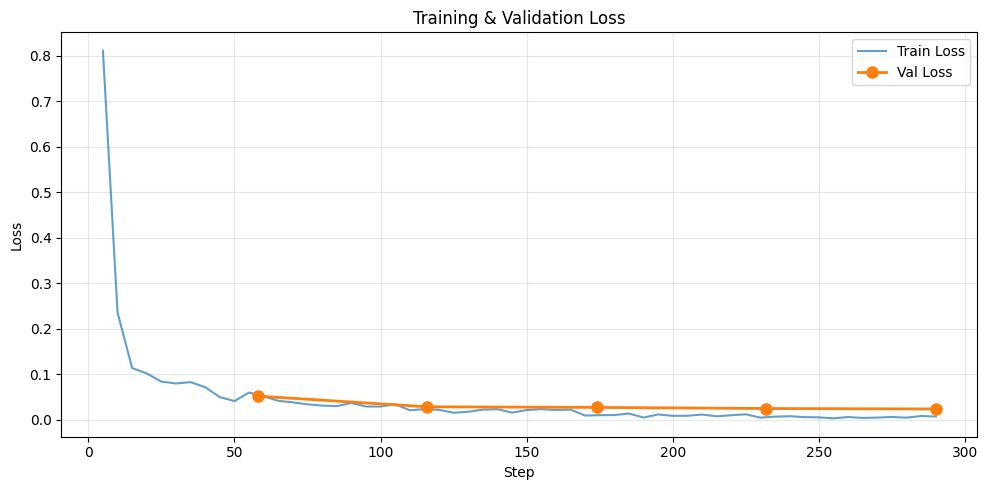

Saved: ./outputs/qwen25-intent-router/loss_curve.png


In [12]:
# ─── Plot training curves ───
import matplotlib.pyplot as plt

history = trainer.state.log_history
train_loss = [(h["step"], h["loss"]) for h in history if "loss" in h and "eval_loss" not in h]
eval_entries = [(h["step"], h["eval_loss"]) for h in history if "eval_loss" in h]

fig, ax = plt.subplots(figsize=(10, 5))
if train_loss:
    steps, losses = zip(*train_loss)
    ax.plot(steps, losses, label="Train Loss", alpha=0.7)
if eval_entries:
    steps, losses = zip(*eval_entries)
    ax.plot(steps, losses, "o-", label="Val Loss", markersize=8, linewidth=2)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/loss_curve.png", dpi=150)
plt.show()
print(f"Saved: {OUTPUT_DIR}/loss_curve.png")


## 5. Đánh giá trên Test Set

Metrics:
- **JSON parse rate**: Model có tạo đúng JSON format không?
- **Intent accuracy**: Phân loại đúng intent?
- **Scope accuracy**: Phân loại đúng scope?
- **Combined accuracy**: Cả intent VÀ scope đều đúng?
- **Per-class accuracy**: Accuracy theo từng intent/scope
- **Confusion matrix**: Visualize lỗi phân loại


In [16]:
# ─── Inference trên test set ───
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# KHÔNG dùng FastLanguageModel.for_inference(model) vì Unsloth fast inference path
# có bug RoPE cache shape mismatch với sequence dài. Dùng HF generate thuần thay thế.
model.eval()

results = []

for i, sample in enumerate(test_raw):
    # Prompt = system + user (KHÔNG có assistant)
    messages = sample["messages"][:2]
    prompt_out = tokenizer.apply_chat_template(
        messages,
        tokenize=True,
        add_generation_prompt=True,  # Thêm "<|im_start|>assistant\n" ở cuối
        return_tensors="pt",
    )
    # apply_chat_template trả về tensor hoặc BatchEncoding tuỳ transformers version
    prompt_ids = prompt_out["input_ids"] if hasattr(prompt_out, "keys") else prompt_out
    prompt_ids = prompt_ids.to(model.device)
    attention_mask = torch.ones_like(prompt_ids)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=prompt_ids,
            attention_mask=attention_mask,
            max_new_tokens=50,
            max_length=None,
            temperature=0.0,
            do_sample=False,
            use_cache=False,        # Tắt KV cache để tránh Unsloth RoPE shape bug
        )

    # Decode phần generated (bỏ prompt)
    generated = tokenizer.decode(
        output_ids[0][prompt_ids.shape[1]:],
        skip_special_tokens=True,
    ).strip()

    expected = json.loads(sample["messages"][2]["content"])

    try:
        predicted = json.loads(generated)
        results.append({
            "question": sample["messages"][1]["content"][:100],
            "expected_intent": expected["intent"],
            "expected_scope": expected["scope"],
            "predicted_intent": predicted.get("intent", "MISSING"),
            "predicted_scope": predicted.get("scope", "MISSING"),
            "raw_output": generated,
            "json_valid": True,
        })
    except json.JSONDecodeError:
        results.append({
            "question": sample["messages"][1]["content"][:100],
            "expected_intent": expected["intent"],
            "expected_scope": expected["scope"],
            "predicted_intent": "JSON_ERROR",
            "predicted_scope": "JSON_ERROR",
            "raw_output": generated,
            "json_valid": False,
        })

    if (i + 1) % 50 == 0:
        print(f"  {i+1}/{len(test_raw)} evaluated...")

df = pd.DataFrame(results)
print(f"\nDone: {len(df)} samples evaluated")
print(f"JSON parse rate: {df['json_valid'].sum()}/{len(df)} ({100*df['json_valid'].mean():.1f}%)")

  50/230 evaluated...
  100/230 evaluated...
  150/230 evaluated...
  200/230 evaluated...

Done: 230 samples evaluated
JSON parse rate: 230/230 (100.0%)


In [17]:
# ─── Compute metrics ───
valid = df[df["json_valid"]].copy()

intent_correct = (valid["expected_intent"] == valid["predicted_intent"]).sum()
scope_correct = (valid["expected_scope"] == valid["predicted_scope"]).sum()
both_correct = (
    (valid["expected_intent"] == valid["predicted_intent"])
    & (valid["expected_scope"] == valid["predicted_scope"])
).sum()

n = len(valid)
print("=" * 50)
print(f"  TEST SET METRICS ({len(df)} samples)")
print("=" * 50)
print(f"  JSON parse rate:     {100*df['json_valid'].mean():.1f}%")
print(f"  Intent accuracy:     {100*intent_correct/n:.1f}% ({intent_correct}/{n})")
print(f"  Scope accuracy:      {100*scope_correct/n:.1f}% ({scope_correct}/{n})")
print(f"  Combined accuracy:   {100*both_correct/n:.1f}% ({both_correct}/{n})")

# Per-intent accuracy
print(f"\n{'─'*50}")
print(f"  Per-Intent Accuracy")
print(f"{'─'*50}")
for intent in sorted(valid["expected_intent"].unique()):
    mask = valid["expected_intent"] == intent
    acc = (valid.loc[mask, "expected_intent"] == valid.loc[mask, "predicted_intent"]).mean()
    total = mask.sum()
    print(f"  {intent:30s}: {100*acc:5.1f}%  ({total} samples)")

# Per-scope accuracy
print(f"\n{'─'*50}")
print(f"  Per-Scope Accuracy")
print(f"{'─'*50}")
for scope in sorted(valid["expected_scope"].unique()):
    mask = valid["expected_scope"] == scope
    acc = (valid.loc[mask, "expected_scope"] == valid.loc[mask, "predicted_scope"]).mean()
    total = mask.sum()
    print(f"  {scope:15s}: {100*acc:5.1f}%  ({total} samples)")

# Show errors
json_errors = df[~df["json_valid"]]
if len(json_errors) > 0:
    print(f"\n{'─'*50}")
    print(f"  JSON Parse Errors ({len(json_errors)})")
    print(f"{'─'*50}")
    for _, row in json_errors.head(10).iterrows():
        print(f"  Q: {row['question']}")
        print(f"  Raw: {row['raw_output']!r}")
        print()

# Show misclassified samples
misclassified = valid[
    (valid["expected_intent"] != valid["predicted_intent"])
    | (valid["expected_scope"] != valid["predicted_scope"])
]
if len(misclassified) > 0:
    print(f"\n{'─'*50}")
    print(f"  Misclassified Samples ({len(misclassified)})")
    print(f"{'─'*50}")
    for _, row in misclassified.head(15).iterrows():
        print(f"  Q: {row['question']}")
        print(f"  Expected: ({row['expected_intent']}, {row['expected_scope']})")
        print(f"  Got:      ({row['predicted_intent']}, {row['predicted_scope']})")
        print()


  TEST SET METRICS (230 samples)
  JSON parse rate:     100.0%
  Intent accuracy:     91.7% (211/230)
  Scope accuracy:      97.4% (224/230)
  Combined accuracy:   89.6% (206/230)

──────────────────────────────────────────────────
  Per-Intent Accuracy
──────────────────────────────────────────────────
  activity_weather              :  93.3%  (15 samples)
  current_weather               :  82.4%  (17 samples)
  daily_forecast                :  80.0%  (15 samples)
  expert_weather_param          :  92.9%  (14 samples)
  historical_weather            :  93.3%  (15 samples)
  hourly_forecast               : 100.0%  (14 samples)
  humidity_fog_query            :  93.3%  (15 samples)
  location_comparison           : 100.0%  (15 samples)
  rain_query                    : 100.0%  (17 samples)
  seasonal_context              :  93.8%  (16 samples)
  smalltalk_weather             :  93.3%  (15 samples)
  temperature_query             :  86.7%  (15 samples)
  weather_alert                 :  

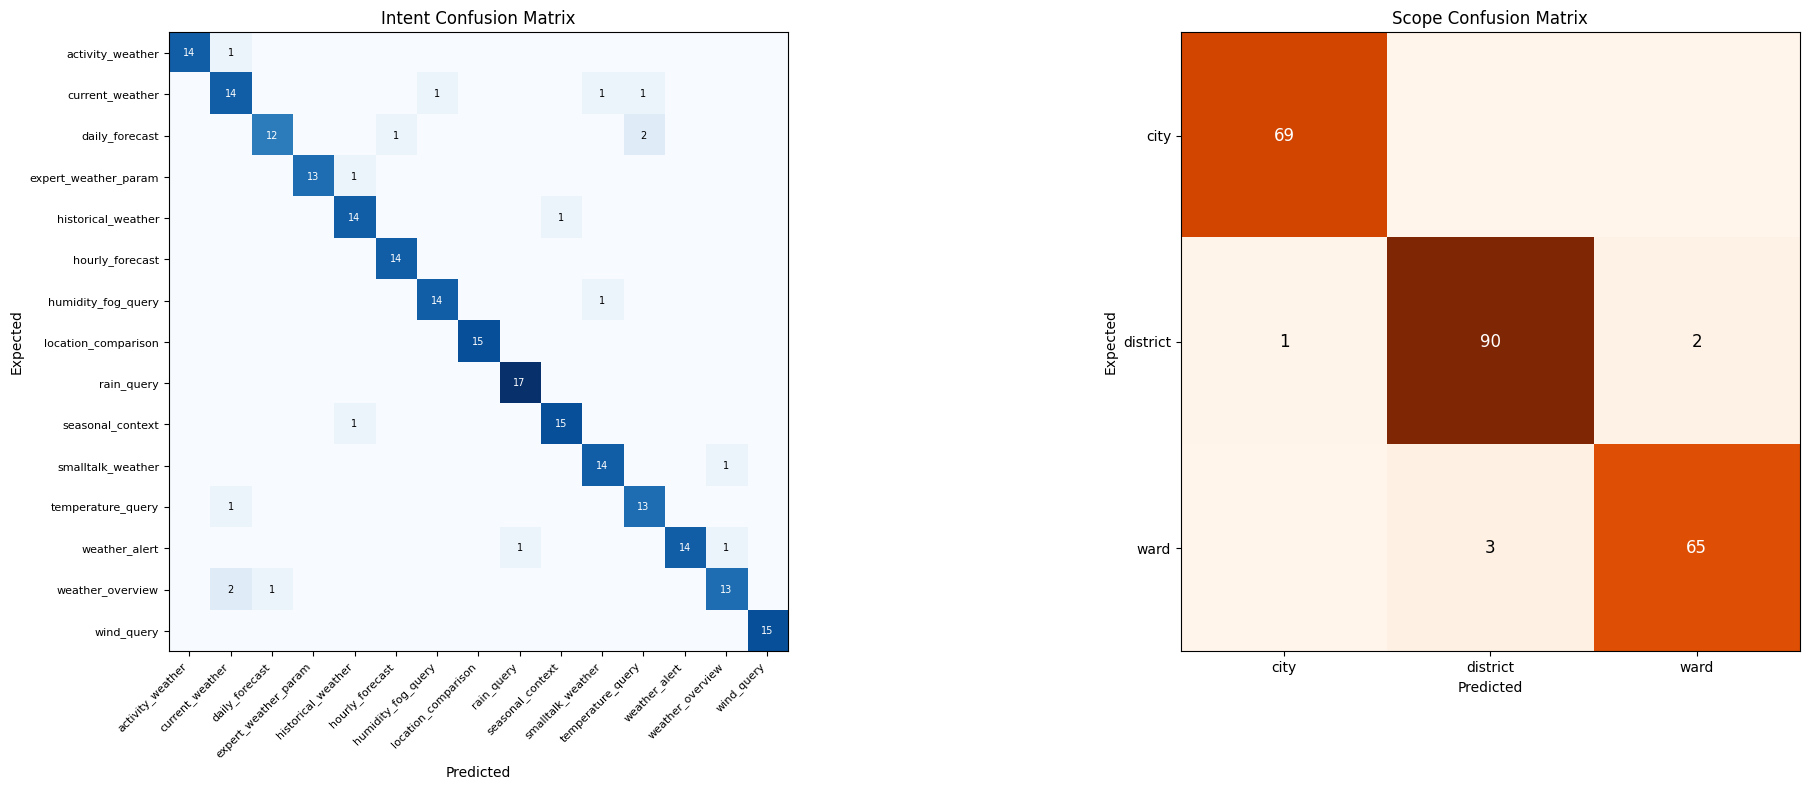

Saved: ./outputs/qwen25-intent-router/confusion_matrices.png

=== Intent Classification Report ===
                      precision    recall  f1-score   support

    activity_weather       1.00      0.93      0.97        15
     current_weather       0.78      0.82      0.80        17
      daily_forecast       0.92      0.80      0.86        15
expert_weather_param       1.00      0.93      0.96        14
  historical_weather       0.88      0.93      0.90        15
     hourly_forecast       0.93      1.00      0.97        14
  humidity_fog_query       0.93      0.93      0.93        15
 location_comparison       1.00      1.00      1.00        15
          rain_query       0.94      1.00      0.97        17
    seasonal_context       0.94      0.94      0.94        16
   smalltalk_weather       0.88      0.93      0.90        15
   temperature_query       0.81      0.87      0.84        15
       weather_alert       1.00      0.88      0.93        16
    weather_overview       0.87 

In [18]:
# ─── Confusion matrices ───
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

valid = df[df["json_valid"]].copy()

# Lọc chỉ valid labels (không phải MISSING/JSON_ERROR)
intent_labels = sorted(valid["expected_intent"].unique())
scope_labels = sorted(valid["expected_scope"].unique())

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

# Intent confusion matrix
cm_intent = confusion_matrix(
    valid["expected_intent"], valid["predicted_intent"],
    labels=intent_labels,
)
im = axes[0].imshow(cm_intent, cmap="Blues")
axes[0].set_xticks(range(len(intent_labels)))
axes[0].set_yticks(range(len(intent_labels)))
axes[0].set_xticklabels(intent_labels, rotation=45, ha="right", fontsize=8)
axes[0].set_yticklabels(intent_labels, fontsize=8)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Expected")
axes[0].set_title("Intent Confusion Matrix")
for i in range(len(intent_labels)):
    for j in range(len(intent_labels)):
        val = cm_intent[i, j]
        if val > 0:
            axes[0].text(j, i, str(val), ha="center", va="center",
                        fontsize=7, color="white" if val > cm_intent.max()/2 else "black")

# Scope confusion matrix
cm_scope = confusion_matrix(
    valid["expected_scope"], valid["predicted_scope"],
    labels=scope_labels,
)
im2 = axes[1].imshow(cm_scope, cmap="Oranges")
axes[1].set_xticks(range(len(scope_labels)))
axes[1].set_yticks(range(len(scope_labels)))
axes[1].set_xticklabels(scope_labels, fontsize=10)
axes[1].set_yticklabels(scope_labels, fontsize=10)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Expected")
axes[1].set_title("Scope Confusion Matrix")
for i in range(len(scope_labels)):
    for j in range(len(scope_labels)):
        val = cm_scope[i, j]
        if val > 0:
            axes[1].text(j, i, str(val), ha="center", va="center",
                        fontsize=12, color="white" if val > cm_scope.max()/2 else "black")

plt.tight_layout()
plt.savefig(OUTPUT_DIR + "/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {OUTPUT_DIR}/confusion_matrices.png")

# Classification reports
print("\n=== Intent Classification Report ===")
print(classification_report(
    valid["expected_intent"], valid["predicted_intent"],
    labels=intent_labels, target_names=intent_labels, zero_division=0,
))

print("\n=== Scope Classification Report ===")
print(classification_report(
    valid["expected_scope"], valid["predicted_scope"],
    labels=scope_labels, target_names=scope_labels, zero_division=0,
))


In [19]:
# ─── Lưu kết quả ───
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

# CSV chi tiết
df.to_csv(OUTPUT_DIR + "/test_results.csv", index=False, encoding="utf-8-sig")

# Summary JSON
summary = {
    "model": MODEL_NAME,
    "lora_r": LORA_R,
    "lora_alpha": LORA_ALPHA,
    "epochs": EPOCHS,
    "effective_batch_size": BATCH_SIZE * GRAD_ACCUM,
    "learning_rate": LEARNING_RATE,
    "train_samples": len(train_raw),
    "val_samples": len(val_raw),
    "test_samples": len(test_raw),
    "json_parse_rate": round(float(df["json_valid"].mean()), 4),
    "intent_accuracy": round(float(intent_correct / n), 4),
    "scope_accuracy": round(float(scope_correct / n), 4),
    "combined_accuracy": round(float(both_correct / n), 4),
    "training_loss": round(float(trainer_stats.training_loss), 4),
}
with open(OUTPUT_DIR + "/summary.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)

print("Saved:")
print(f"  {OUTPUT_DIR}/test_results.csv")
print(f"  {OUTPUT_DIR}/summary.json")
print(f"\nSummary: {json.dumps(summary, indent=2)}")


Saved:
  ./outputs/qwen25-intent-router/test_results.csv
  ./outputs/qwen25-intent-router/summary.json

Summary: {
  "model": "unsloth/Qwen2.5-1.5B-Instruct-bnb-4bit",
  "lora_r": 16,
  "lora_alpha": 32,
  "epochs": 5,
  "effective_batch_size": 32,
  "learning_rate": 0.0002,
  "train_samples": 1830,
  "val_samples": 230,
  "test_samples": 230,
  "json_parse_rate": 1.0,
  "intent_accuracy": 0.9174,
  "scope_accuracy": 0.9739,
  "combined_accuracy": 0.8957,
  "training_loss": 0.0433
}


## 6. Export model

Export 3 formats:
1. **LoRA adapter** — nhẹ (~30MB), cần base model để inference
2. **GGUF q8_0** — cho inference local (llama.cpp / llama-cpp-python), accuracy cao nhất
3. **GGUF q4_k_m** — nhỏ hơn, nếu cần tiết kiệm RAM


In [ ]:
# ─── Save LoRA adapter ───
lora_dir = OUTPUT_DIR + "/lora"
model.save_pretrained(lora_dir)
tokenizer.save_pretrained(lora_dir)
print(f"LoRA adapter saved: {lora_dir}")

# Tính kích thước
import os
lora_size = sum(
    os.path.getsize(os.path.join(dp, f))
    for dp, _, fns in os.walk(lora_dir) for f in fns
) / 1024**2
print(f"LoRA size: {lora_size:.1f} MB")


In [ ]:
# ─── Export GGUF q8_0 (recommended cho classification) ───
print("Exporting GGUF q8_0 (best accuracy)...")
model.save_pretrained_gguf(
    OUTPUT_DIR + "/gguf-q8",
    tokenizer,
    quantization_method="q8_0",
)
print("Done!")

# ─── Export GGUF q4_k_m (smaller, optional) ───
print("\nExporting GGUF q4_k_m (smaller)...")
model.save_pretrained_gguf(
    OUTPUT_DIR + "/gguf-q4",
    tokenizer,
    quantization_method="q4_k_m",
)
print("Done!")

# Show file sizes
import glob
for pattern in ["/gguf-q8/*.gguf", "/gguf-q4/*.gguf"]:
    for f in glob.glob(OUTPUT_DIR + pattern):
        size_mb = os.path.getsize(f) / 1024**2
        print(f"  {Path(f).name}: {size_mb:.1f} MB")


## 7. Quick inference test

In [20]:
# ─── Test với các câu hỏi đa dạng ───
test_questions = [
    "Hà Nội bây giờ thời tiết thế nào?",                     # current_weather, city
    "Dự báo 3 ngày tới ở Cầu Giấy?",                        # daily_forecast, district
    "Phường Dịch Vọng Hậu có mưa không?",                    # rain_query, ward
    "Hồ Gươm có gió mạnh không?",                            # wind_query, district (POI→district)
    "So sánh thời tiết Ba Đình và Hoàn Kiếm?",               # location_comparison, district
    "Áp suất khí quyển hôm nay bao nhiêu?",                  # expert_weather_param, city
    "thoi tiet ha noi hom nay the nao",                       # no diacritics → current_weather, city
    "Sóc Sơn cuối tuần có mưa không?",                       # rain_query, district
    "Xin chào!",                                              # smalltalk_weather, city
    "Chỉ số UV ở khu vực Hồ Tây?",                           # expert_weather_param, district
]

# Lấy system prompt từ training data
system_prompt = train_raw[0]["messages"][0]["content"]

print("=" * 60)
print("  QUICK INFERENCE TEST")
print("=" * 60)

for q in test_questions:
    messages = [
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": q},
    ]
    prompt_out = tokenizer.apply_chat_template(
        messages, tokenize=True,
        add_generation_prompt=True, return_tensors="pt",
    )
    prompt_ids = prompt_out["input_ids"] if hasattr(prompt_out, "keys") else prompt_out
    prompt_ids = prompt_ids.to(model.device)
    attention_mask = torch.ones_like(prompt_ids)

    with torch.no_grad():
        output_ids = model.generate(
            input_ids=prompt_ids,
            attention_mask=attention_mask,
            max_new_tokens=50,
            max_length=None,
            temperature=0.0, do_sample=False,
            use_cache=False,
        )
    generated = tokenizer.decode(output_ids[0][prompt_ids.shape[1]:], skip_special_tokens=True).strip()
    print(f"  Q: {q}")
    print(f"  A: {generated}")
    print()

  QUICK INFERENCE TEST
  Q: Hà Nội bây giờ thời tiết thế nào?
  A: {"intent": "current_weather", "scope": "city"}

  Q: Dự báo 3 ngày tới ở Cầu Giấy?
  A: {"intent": "daily_forecast", "scope": "district"}

  Q: Phường Dịch Vọng Hậu có mưa không?
  A: {"intent": "rain_query", "scope": "ward"}

  Q: Hồ Gươm có gió mạnh không?
  A: {"intent": "wind_query", "scope": "district"}

  Q: So sánh thời tiết Ba Đình và Hoàn Kiếm?
  A: {"intent": "location_comparison", "scope": "district"}

  Q: Áp suất khí quyển hôm nay bao nhiêu?
  A: {"intent": "expert_weather_param", "scope": "city"}

  Q: thoi tiet ha noi hom nay the nao
  A: {"intent": "current_weather", "scope": "city"}

  Q: Sóc Sơn cuối tuần có mưa không?
  A: {"intent": "rain_query", "scope": "district"}

  Q: Xin chào!
  A: {"intent": "smalltalk_weather", "scope": "city"}

  Q: Chỉ số UV ở khu vực Hồ Tây?
  A: {"intent": "expert_weather_param", "scope": "district"}



## 8. Download / Copy to Drive

In [22]:
import shutil

if USE_DRIVE:
    # Copy outputs to Drive
    drive_model_dir = Path(DRIVE_PATH).parent / "model"
    drive_model_dir.mkdir(parents=True, exist_ok=True)

    # Copy LoRA
    lora_src = OUTPUT_DIR + "/lora"
    if os.path.exists(lora_src):
        shutil.copytree(lora_src, str(drive_model_dir / "lora"), dirs_exist_ok=True)
        print(f"Copied: lora/")
    else:
        print(f"SKIP: {lora_src} not found (run Export cell first)")

    # Copy GGUF
    for variant in ["gguf-q8", "gguf-q4"]:
        src = OUTPUT_DIR + f"/{variant}"
        if os.path.exists(src):
            shutil.copytree(src, str(drive_model_dir / variant), dirs_exist_ok=True)
            print(f"Copied: {variant}/")
        else:
            print(f"SKIP: {src} not found")

    # Copy metrics
    for f in ["summary.json", "test_results.csv", "loss_curve.png", "confusion_matrices.png"]:
        src = OUTPUT_DIR + f"/{f}"
        if os.path.exists(src):
            shutil.copy2(src, str(drive_model_dir / f))
            print(f"Copied: {f}")

    print(f"\nAll available outputs copied to Drive: {drive_model_dir}")
    print(f"\nFiles:")
    for p in sorted(drive_model_dir.rglob("*")):
        if p.is_file():
            print(f"  {p.relative_to(drive_model_dir)} ({p.stat().st_size/1024**2:.1f} MB)")
else:
    # Download GGUF files
    from google.colab import files
    for pattern in ["/gguf-q8/*.gguf", "/gguf-q4/*.gguf"]:
        for f in glob.glob(OUTPUT_DIR + pattern):
            print(f"Downloading: {f}")
            files.download(f)

SKIP: ./outputs/qwen25-intent-router/lora not found (run Export cell first)
SKIP: ./outputs/qwen25-intent-router/gguf-q8 not found
SKIP: ./outputs/qwen25-intent-router/gguf-q4 not found
Copied: summary.json
Copied: test_results.csv
Copied: loss_curve.png
Copied: confusion_matrices.png

All available outputs copied to Drive: /content/drive/MyDrive/Chatbot_HanoiAir/data/model

Files:
  confusion_matrices.png (0.2 MB)
  loss_curve.png (0.0 MB)
  summary.json (0.0 MB)
  test_results.csv (0.0 MB)


## Done!

**Output files:**
- `lora/` — LoRA adapter (dùng với PEFT + base model)
- `gguf-q8/*.gguf` — GGUF q8_0 (recommended, dùng với llama.cpp)
- `gguf-q4/*.gguf` — GGUF q4_k_m (nhỏ hơn)
- `summary.json` — Metrics tổng hợp
- `test_results.csv` — Chi tiết từng test sample
- `loss_curve.png` — Training/val loss
- `confusion_matrices.png` — Confusion matrices

**Tiếp theo (Phase 3):** Tích hợp GGUF model vào Router Infrastructure
(`slm_router.py`, `tool_mapper.py`, `model_factory.py`)
